In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm

A weighted Bayesian update with weighting parameter $\omega$ between two normal distributions $p_0(x) = \mathcal{N}(x; \mu_0, \sigma_0^2), \quad p_1(x) = \mathcal{N}(x; \mu_1, \sigma_1^2)$ is given by:

$$
\begin{equation}
\begin{aligned}
\mu_{post} &= \frac{(1-\lambda)\mu_0\pi_0 + \lambda\mu_1\pi_1}{(1-\lambda)\pi_0 + \lambda \pi_1} \\
\pi_{post} &= (1-\lambda)\pi_0 + \lambda \pi_1 \\
\end{aligned}
\end{equation}
$$

If $\mu_{post}$ and $\pi_{post}$ are known, we can retrieve $\lambda$ by solving:

$$
\begin{equation}
\begin{aligned}
\pi_{post} &= (1-\lambda) \pi_0 + \lambda \pi_1 \\
\pi_{post} &= \pi_0 -\lambda\pi_0 + \lambda \pi_1 \\
\pi_{post} - \pi_0 &= \lambda (-\pi_0 + \pi_1) \\
\lambda &= \frac{\pi_{post} - \pi_0}{-\pi_0 + \pi_1} \\
\end{aligned}
\end{equation}
$$

This works unless $pi_0 = pi_1$, in which case the weight is simply the proportion of update between $\mu_0$ and $\mu_1$:

In [2]:
def weighted_bayesian_update(
    mu_0: float, mu_1: float, pi_0: float, pi_1: float, lam: float
):
    """Bayesian update for the mean and precision of a normal distribution."""
    pi = (1 - lam) * pi_0 + lam * pi_1
    mu = ((1 - lam) * mu_0 * pi_0 + lam * mu_1 * pi_1) / pi
    return mu, pi

In [3]:
mu_0, pi_0 = 50, 0.25  # cardiac prior
mu_1, pi_1 = 70, 1.0  # cardiac signal

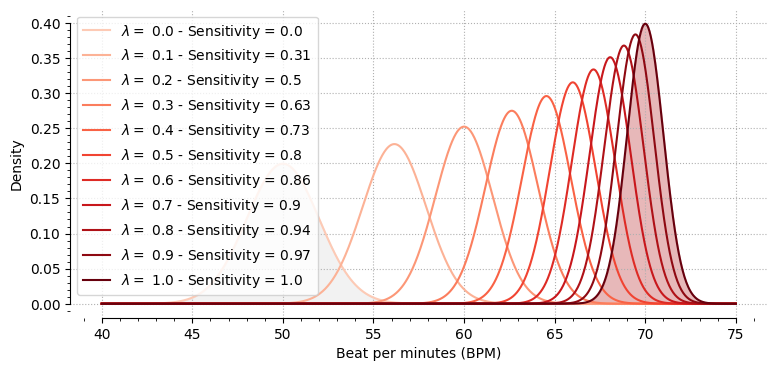

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))

x = np.linspace(40, 75, 1000)
for lam, color in zip(np.arange(0, 1.1, 0.1), plt.cm.Reds(np.linspace(0.2, 1, 11))):
    # extract the sufficient statistics from the input node (and parents)
    mu, pi = weighted_bayesian_update(mu_0, mu_1, pi_0, pi_1, lam)
    # sensitivity = (mu - mu_0) / (mu_1 - mu_0)
    sensitivity = (lam * pi_1) / pi

    # the model expectations
    ax.plot(
        x,
        norm(mu, np.sqrt(1 / pi)).pdf(x),
        color=color,
        label=rf"$\lambda = $ {round(lam, 2)} - Sensitivity = {round(sensitivity, 2)}",
    )

# the sampling distribution
ax.fill_between(x, norm(mu_0, np.sqrt(1 / pi_0)).pdf(x), color="grey", alpha=0.1)
ax.fill_between(x, norm(mu_1, np.sqrt(1 / pi_1)).pdf(x), color="#c44e52", alpha=0.4)
ax.legend()
ax.minorticks_on()
ax.set(xlabel="Beat per minutes (BPM)", ylabel="Density")
plt.grid(linestyle=":")
sns.despine(trim=5)